In [6]:
import json
import os
import numpy as np

In [7]:
runs_eval_path = '/vision/asomaya1/active-rir/runs_eval'
stats_file_name = 'val_YmJkqBEsHnH_stats_0.json'

#specify model to run
run = 'YmJkqBEsHnH'

full_path = os.path.join(runs_eval_path, run, "tb", stats_file_name)


# Open and load the JSON file
with open(full_path, 'r') as json_file:
    print(full_path)
    data = json.load(json_file)

/vision/asomaya1/active-rir/runs_eval/YmJkqBEsHnH/tb/val_YmJkqBEsHnH_stats_0.json


In [8]:
data

{'data/scene_datasets/mp3d/YmJkqBEsHnH/YmJkqBEsHnH.glb,702': {'reward': 146.8636474609375,
  'stft_l1_distance': 0.022213237080723047}}

In [9]:
# Dictionary to store aggregated metrics for each scene
scene_metrics = {}

# Iterate through the dictionary and group metrics by scene
for key, metrics in data.items():
    # Split the key to extract the scene name
    parts = key.split('/')
    scene_name = parts[3]  # Assuming the scene name is always in the fourth position
    if scene_name not in scene_metrics:
        scene_metrics[scene_name] = {
            'reward': [],
            'stft_l1_distance': [],
            'diff_rt_startFrom60dB': [],
            #'rel_diff_rt_startFrom60dB': [],
            #'rel_diff_edt': [],
            #'diff_drr_3ms': [],
            #'rel_diff_drr_3ms': [],
            #'diff_ratio_lrEnergy': [],
        }
    
    # Append metrics to the scene-specific list
    scene_metrics[scene_name]['reward'].append(metrics['reward'])
    scene_metrics[scene_name]['stft_l1_distance'].append(metrics['stft_l1_distance'])
    scene_metrics[scene_name]['diff_rt_startFrom60dB'].append(metrics['diff_rt_startFrom60dB'])
    #scene_metrics[scene_name]['rel_diff_rt_startFrom60dB'].append(metrics['rel_diff_rt_startFrom60dB'])
    #scene_metrics[scene_name]['rel_diff_edt'].append(metrics['rel_diff_edt'])
    #scene_metrics[scene_name]['diff_drr_3ms'].append(metrics['diff_drr_3ms'])
    #scene_metrics[scene_name]['rel_diff_drr_3ms'].append(metrics['rel_diff_drr_3ms'])
    #scene_metrics[scene_name]['diff_ratio_lrEnergy'].append(metrics['diff_ratio_lrEnergy'])

# Compute the average metrics for each scene
average_scene_metrics = {}
for scene_name, metrics in scene_metrics.items():
    average_scene_metrics[scene_name] = {
        'average_reward': sum(metrics['reward']) / len(metrics['reward']),
        'average_stft_l1_distance': sum(metrics['stft_l1_distance']) / len(metrics['stft_l1_distance']),
        'average_diff_rt_startFrom60dB': sum(metrics['diff_rt_startFrom60dB']) / len(metrics['diff_rt_startFrom60dB']),
        #'average_rel_diff_rt_startFrom60dB': sum(metrics['rel_diff_rt_startFrom60dB']) / len(metrics['rel_diff_rt_startFrom60dB']),
        #'average_rel_diff_edt': sum(metrics['rel_diff_edt']) / len(metrics['rel_diff_edt']),
        'average_diff_drr_3ms': sum(metrics['diff_drr_3ms']) / len(metrics['diff_drr_3ms']),
        #'average_rel_diff_drr_3ms': sum(metrics['rel_diff_drr_3ms']) / len(metrics['rel_diff_drr_3ms']),
        #'average_diff_ratio_lrEnergy': sum(metrics['diff_ratio_lrEnergy']) / len(metrics['diff_ratio_lrEnergy']),
    }

# Print the average metrics for each scene
for scene_name, metrics in average_scene_metrics.items():
    print(f'Scene: {scene_name}')
    print(f'Average Reward: {metrics["average_reward"]}')
    print(f'Average STFT L1 Distance: {metrics["average_stft_l1_distance"]}')
    print(f'Average Diff RT StartFrom60dB: {metrics["average_diff_rt_startFrom60dB"]}')
    #print(f'Average Rel Diff RT StartFrom60dB: {metrics["average_rel_diff_rt_startFrom60dB"]}')
    #print(f'Average Rel Diff EDT: {metrics["average_rel_diff_edt"]}')
    print(f'Average Diff DRR 3ms: {metrics["average_diff_drr_3ms"]}')
    #print(f'Average Rel Diff DRR 3ms: {metrics["average_rel_diff_drr_3ms"]}')
    #print(f'Average Diff Ratio lrEnergy: {metrics["average_diff_ratio_lrEnergy"]}')
    print()

KeyError: 'diff_rt_startFrom60dB'

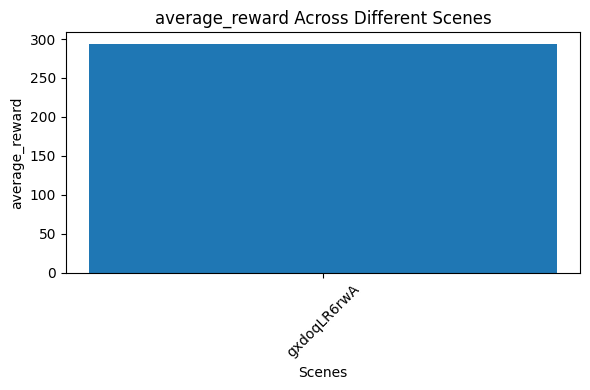

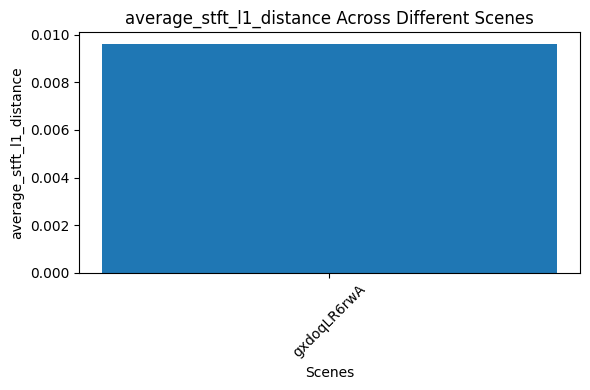

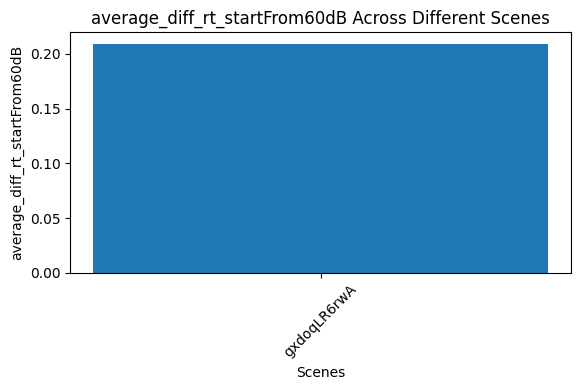

KeyError: 'average_rel_diff_rt_startFrom60dB'

In [ ]:
import matplotlib.pyplot as plt

# Metrics to plot
metrics_to_plot = [
    'average_reward',
    'average_stft_l1_distance',
    'average_diff_rt_startFrom60dB',
    'average_rel_diff_rt_startFrom60dB',
    'average_rel_diff_edt',
    'average_diff_drr_3ms',
    'average_rel_diff_drr_3ms',
    'average_diff_ratio_lrEnergy',
]

# Create a bar plot for each metric
for metric in metrics_to_plot:
    # Extract metric values for all scenes
    metric_values = [average_scene_metrics[scene][metric] for scene in average_scene_metrics]
    scenes = list(average_scene_metrics.keys())

    # Create the bar plot
    plt.figure(figsize=(6, 4))
    plt.bar(scenes, metric_values)
    plt.xlabel('Scenes')
    plt.ylabel(metric)
    plt.title(f'{metric} Across Different Scenes')
    plt.xticks(rotation=45)
    plt.tight_layout()

    # Show or save the plot (you can choose either option)
    # To show the plot:
    plt.show()

    # To save the plot as an image file (e.g., PNG):
    # plt.savefig(f'{metric}_bar_plot.png')


In [ ]:
with open("/vision/asomaya1/active-rir/data/metadata/scene_sizes.json", "rb") as f:
    scene_sizes = json.load(f)

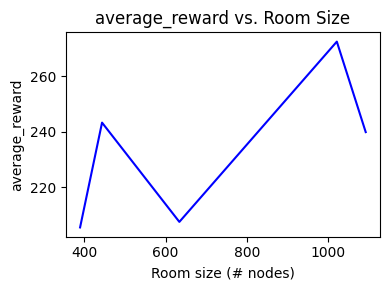

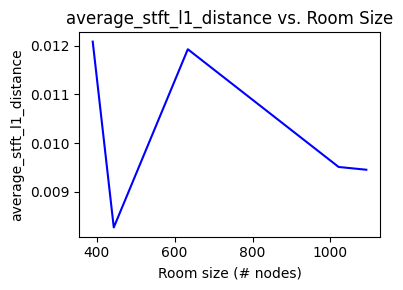

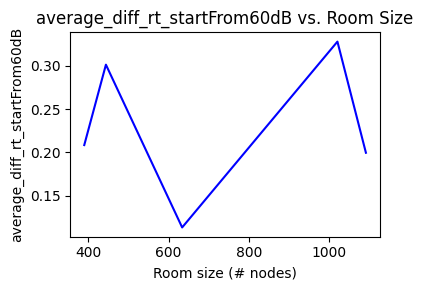

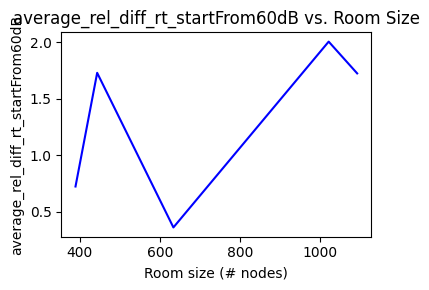

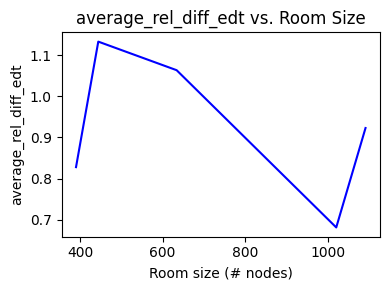

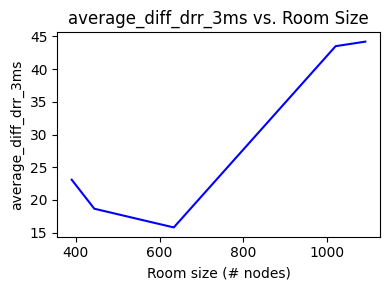

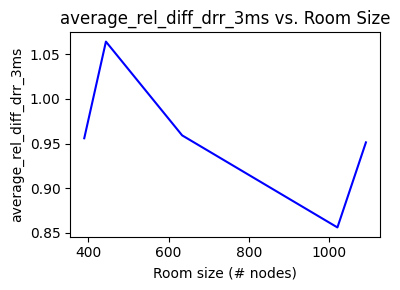

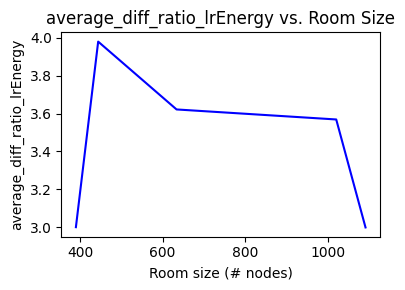

In [ ]:
# Create scatter plots for each metric as a function of the integer
for metric in metrics_to_plot:
    # Extract metric values for all scenes
    metric_values = [average_scene_metrics[scene][metric] for scene in average_scene_metrics]
    integers = [scene_sizes[scene] for scene in average_scene_metrics]

    sorted_data = sorted(zip(integers, metric_values), key=lambda x: x[0])
    sorted_integers, sorted_metric_values = zip(*sorted_data)

    plt.figure(figsize=(4, 3))  # Adjust the figsize if needed
    plt.plot(sorted_integers, sorted_metric_values, linestyle='-', color='b')  # Line connecting points
    plt.xlabel('Room size (# nodes)')
    plt.ylabel(metric)
    plt.title(f'{metric} vs. Room Size')
    plt.tight_layout()
    plt.show()


In [ ]:
# Calculate mean, median, and std for each key
results = {}
round_val = 5

first_episode_name = list(data.keys())[0]

for key in data[first_episode_name].keys():
    values = [inner_dict[key] for inner_dict in data.values()]
    mean = np.mean(values)
    median = np.median(values)
    std = np.std(values)
    
    results[key] = {'mean': np.round(mean,round_val), 'median': np.round(median,round_val), 'std': np.round(std,round_val)}

# Print the results
for key, stats in results.items():
    print(f"Key: {key}")
    print(f"Mean: {stats['mean']}")
    #print(f"Median: {stats['median']}")
    #print(f"Standard Deviation: {stats['std']}")
    #print()


Key: reward
Mean: 235.69131
Key: stft_l1_distance
Mean: 0.01007
Key: diff_rt_startFrom60dB
Mean: 0.24123
Key: rel_diff_rt_startFrom60dB
Mean: 1.40157
Key: rel_diff_edt
Mean: 0.91658
Key: diff_drr_3ms
Mean: 30.20564
Key: rel_diff_drr_3ms
Mean: 0.96017
Key: diff_ratio_lrEnergy
Mean: 3.40684


Key: stft_l1_distance
ss Mean: 0.01127
Key: diff_rt_startFrom60dB
Mean: 0.17651
Key: rel_diff_rt_startFrom60dB
Mean: 1.08234
Key: rel_diff_edt
Mean: 0.84656
Key: diff_drr_3ms
Mean: 30.62813
Key: rel_diff_drr_3ms
Mean: 0.86542
Key: diff_ratio_lrEnergy
Mean: 3.39336

Key: stft_l1_distance
Mean: 0.01031
Key: diff_rt_startFrom60dB
Mean: 0.2239
Key: diff_drr_3ms
Mean: 30.40948
Key: rel_diff_rt_startFrom60dB
Mean: 1.3106
Key: rel_diff_drr_3ms
Mean: 0.91214
Key: diff_ratio_lrEnergy
Mean: 3.41826
Key: rel_diff_edt
Mean: 0.91433

Key: stft_l1_distance
Mean: 0.01053
Key: diff_rt_startFrom60dB
Mean: 0.21245
Key: rel_diff_rt_startFrom60dB
Mean: 1.26458
Key: rel_diff_edt
Mean: 0.88086
Key: diff_drr_3ms
Mean: 30.43718
Key: rel_diff_drr_3ms
Mean: 0.92805
Key: diff_ratio_lrEnergy
Mean: 3.40025